# BigBazaar Sales — Demand Prediction Project
**Dataset:** Bigbazaar_sales_data.csv  
**Target Variable:** `Item_Outlet_Sales`  
**Goal:** Predict sales demand using machine learning models

---

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries imported successfully!')

Libraries imported successfully!


In [2]:
df = pd.read_csv("C:\\Users\\PRATHIBA\\OneDrive\\Documents\\ML\\Bigbazaar_sales_data.csv")
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
df.head()

Shape: (14204, 13)

Columns: ['Item_Identifier', 'Item_Weight', 'Item_Visibility', 'Month', 'Outlet_Identifier', 'Item_Type', 'Item_MRP', 'MRP_Level', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Outlet_Sales', 'Converted Sales']


,Item_Identifier,Item_Weight,Item_Visibility,Month,Outlet_Identifier,Item_Type,Item_MRP,MRP_Level,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Converted Sales
0,FDA15,9.30,0.016047,17,OUT049,Dairy,249.8092,Very_High,2,Tier 1,Supermarket Type1,3735.1380,2.428
1,DRC01,5.92,0.019278,7,OUT018,Soft Drinks,48.2692,Low,2,Tier 3,Supermarket Type2,443.4228,0.288
2,FDN15,17.50,0.016760,17,OUT049,Meat,141.6180,High,2,Tier 1,Supermarket Type1,2097.2700,1.363
3,FDX07,19.20,0.022930,18,OUT010,Fruits and Vegetables,182.0950,High,2,Tier 3,Grocery Store,732.3800,0.476
4,NCD19,8.93,0.014670,29,OUT013,Household,53.8614,Low,1,Tier 3,Supermarket Type1,994.7052,0.647


In [3]:
# Basic info, summary, missing values
df.info()
print('\n', df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14204 entries, 0 to 14203
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Item_Identifier       14204 non-null  object 
 1   Item_Weight           14204 non-null  float64
 2   Item_Visibility       14204 non-null  float64
 3   Month                 14204 non-null  int64  
 4   Outlet_Identifier     14204 non-null  object 
 5   Item_Type             14204 non-null  object 
 6   Item_MRP              14204 non-null  float64
 7   MRP_Level             14204 non-null  object 
 8   Outlet_Size           14204 non-null  int64  
 9   Outlet_Location_Type  14204 non-null  object 
 10  Outlet_Type           14204 non-null  object 
 11  Item_Outlet_Sales     14204 non-null  float64
 12  Converted Sales       14204 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 1.4+ MB

         Item_Weight  Item_Visibility         Month      Item_M

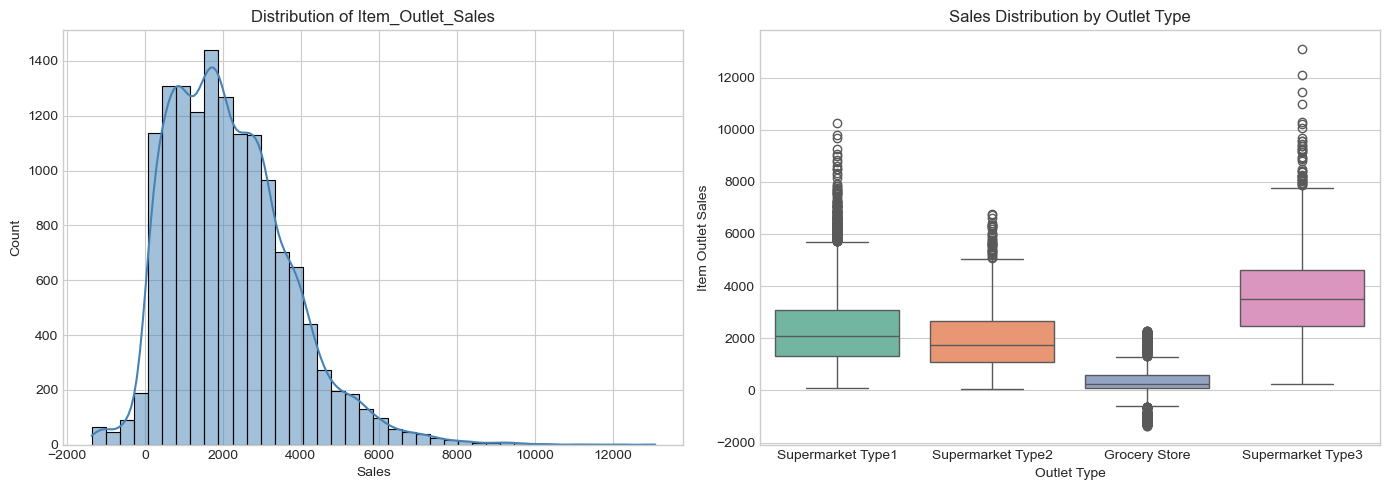

In [4]:
# Target distribution & Sales by Outlet Type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Item_Outlet_Sales'], bins=40, color='steelblue', kde=True, ax=axes[0])
axes[0].set_title('Distribution of Item_Outlet_Sales')
axes[0].set_xlabel('Sales')

sns.boxplot(x='Outlet_Type', y='Item_Outlet_Sales', data=df, palette='Set2', ax=axes[1])
axes[1].set_title('Sales Distribution by Outlet Type')
axes[1].set_xlabel('Outlet Type')
axes[1].set_ylabel('Item Outlet Sales')

plt.tight_layout()
plt.show()

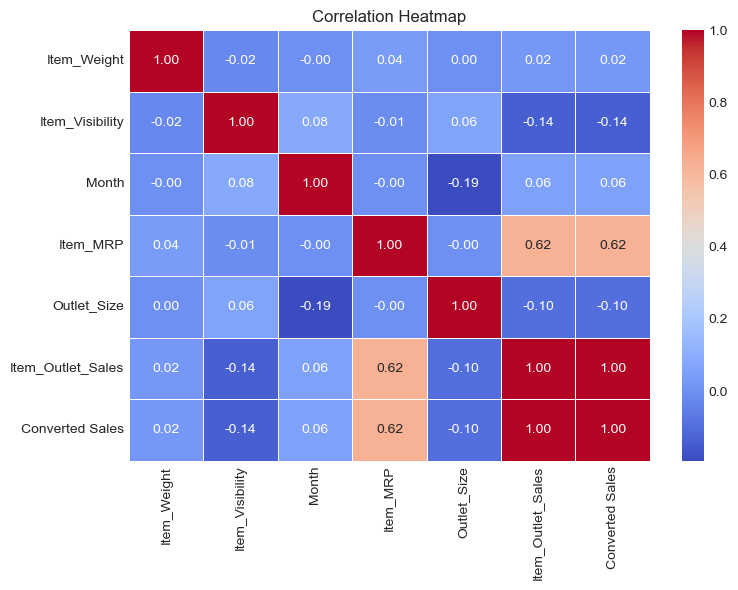

In [5]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [6]:
# Work on a copy, drop non-useful columns
data = df.copy()
data.drop(columns=['Item_Identifier', 'Outlet_Identifier', 'Converted Sales'], inplace=True)

# Label encode categorical columns
cat_cols = ['Item_Type', 'MRP_Level', 'Outlet_Location_Type', 'Outlet_Type']
le = LabelEncoder()
for col in cat_cols:
    data[col] = le.fit_transform(data[col])

# Remove negative sales
data = data[data['Item_Outlet_Sales'] >= 0]
print('Dataset size after cleaning:', data.shape)
data.head()

Dataset size after cleaning: (13921, 10)


,Item_Weight,Item_Visibility,Month,Item_Type,Item_MRP,MRP_Level,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,9.30,0.016047,17,4,249.8092,3,2,0,1,3735.1380
1,5.92,0.019278,7,14,48.2692,1,2,2,2,443.4228
2,17.50,0.016760,17,10,141.6180,0,2,0,1,2097.2700
3,19.20,0.022930,18,6,182.0950,0,2,2,0,732.3800
4,8.93,0.014670,29,9,53.8614,1,1,2,1,994.7052


In [7]:
X = data.drop(columns=['Item_Outlet_Sales'])
y = data['Item_Outlet_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Features:', X.columns.tolist())
print('Train size:', X_train.shape, '| Test size:', X_test.shape)

Features: ['Item_Weight', 'Item_Visibility', 'Month', 'Item_Type', 'Item_MRP', 'MRP_Level', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']
Train size: (11136, 9) | Test size: (2785, 9)


In [8]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    
    return model, y_pred, {
        'Model': name,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'R2': round(r2, 4)
    }

In [9]:
lr_model, lr_pred, lr_scores = evaluate_model(
    'Linear Regression', LinearRegression(),
    X_train, X_test, y_train, y_test
)

dt_model, dt_pred, dt_scores = evaluate_model(
    'Decision Tree', DecisionTreeRegressor(random_state=42, max_depth=8),
    X_train, X_test, y_train, y_test
)

rf_model, rf_pred, rf_scores = evaluate_model(
    'Random Forest', RandomForestRegressor(n_estimators=100, random_state=42),
    X_train, X_test, y_train, y_test
)

gb_model, gb_pred, gb_scores = evaluate_model(
    'Gradient Boosting', GradientBoostingRegressor(n_estimators=100, random_state=42),
    X_train, X_test, y_train, y_test
)

In [10]:
results = pd.DataFrame([lr_scores, dt_scores, rf_scores, gb_scores])
results = results.sort_values('R2', ascending=False).reset_index(drop=True)
results

,Model,MAE,RMSE,R2
0,Gradient Boosting,521.57,847.20,0.6806
1,Random Forest,583.11,896.00,0.6427
2,Decision Tree,555.83,899.82,0.6396
3,Linear Regression,656.94,953.49,0.5954


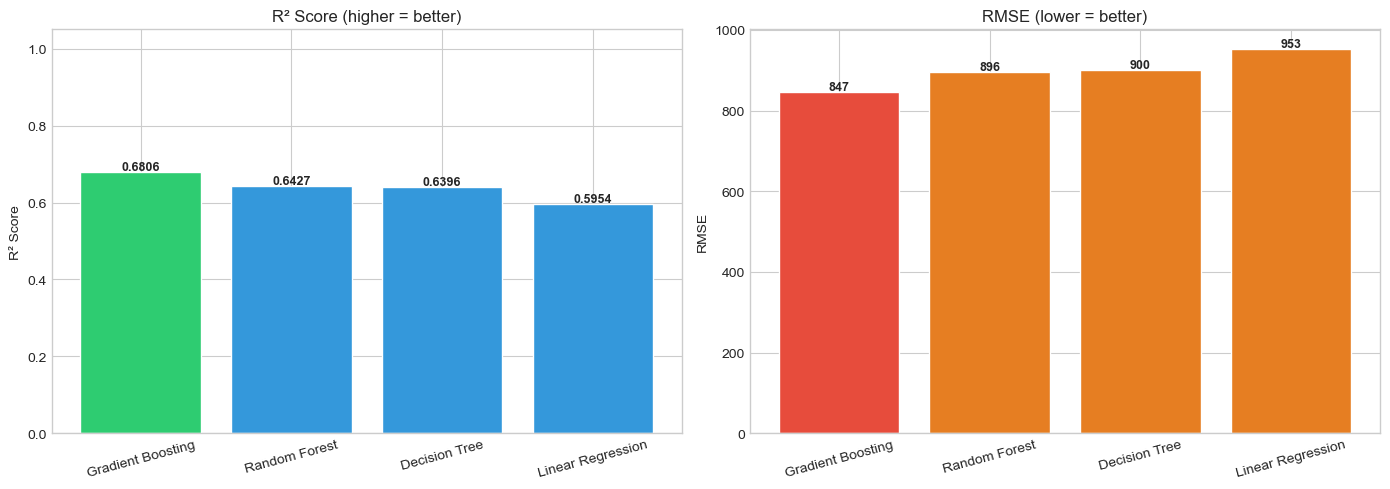

In [11]:
# Combined R² and RMSE comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_r2   = ['#2ecc71' if r == results['R2'].max()   else '#3498db' for r in results['R2']]
colors_rmse = ['#e74c3c' if r == results['RMSE'].min() else '#e67e22' for r in results['RMSE']]

bars1 = axes[0].bar(results['Model'], results['R2'],   color=colors_r2,   edgecolor='white')
for bar, val in zip(bars1, results['R2']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('R² Score (higher = better)')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis='x', rotation=15)

bars2 = axes[1].bar(results['Model'], results['RMSE'], color=colors_rmse, edgecolor='white')
for bar, val in zip(bars2, results['RMSE']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, f'{val:.0f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('RMSE (lower = better)')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

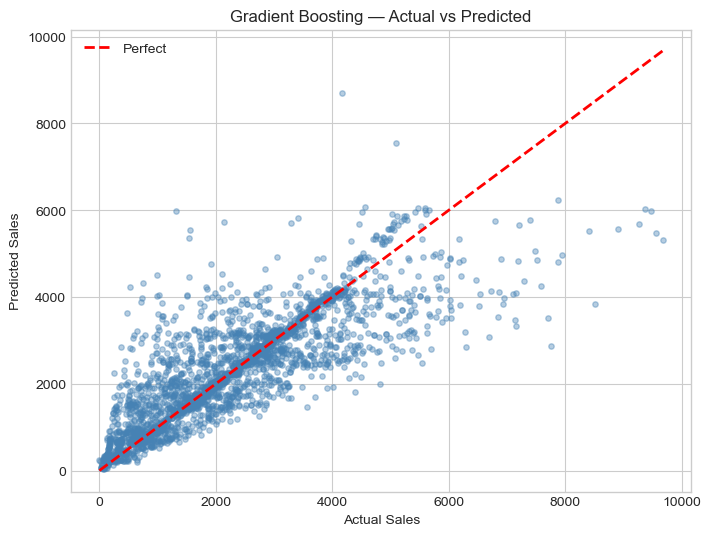

In [12]:
best_pred = gb_pred
best_name = 'Gradient Boosting'
residuals = y_test - best_pred

fig, ax = plt.subplots(figsize=(8, 6))

# Actual vs Predicted
ax.scatter(y_test, best_pred, alpha=0.4, color='steelblue', s=15)
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--', linewidth=2, label='Perfect')

ax.set_xlabel('Actual Sales')
ax.set_ylabel('Predicted Sales')
ax.set_title(f'{best_name} — Actual vs Predicted')
ax.legend()

plt.show()

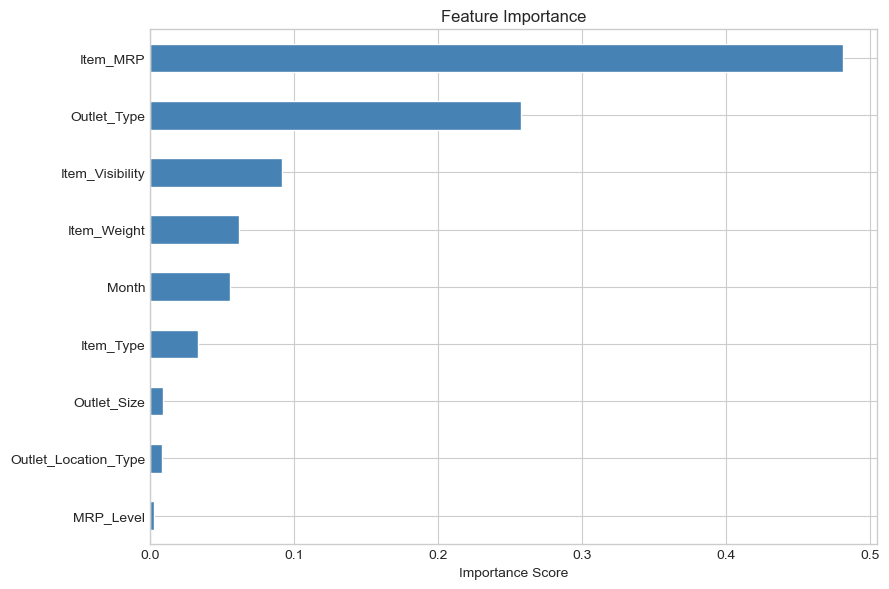


Top Features:
Item_MRP                0.481104
Outlet_Type             0.257640
Item_Visibility         0.091544
Item_Weight             0.061434
Month                   0.055513
Item_Type               0.033089
Outlet_Size             0.008837
Outlet_Location_Type    0.008125
MRP_Level               0.002714
dtype: float64


In [16]:
# Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop Features:')
print(importances.sort_values(ascending=False))

In [14]:
# Predict New Sales
# Example: Dairy item, High MRP, Tier 1 Supermarket
new_item = pd.DataFrame([{
    'Item_Weight'          : 12.5,
    'Item_Visibility'      : 0.05,
    'Month'                 : 17,
    'Item_Type'            : 3,
    'Item_MRP'             : 200.0,
    'MRP_Level'            : 2,
    'Outlet_Size'          : 2,
    'Outlet_Location_Type' : 0,
    'Outlet_Type'          : 2
}])

predicted_sales = gb_model.predict(new_item)[0]
print(f'Predicted Sales for new item: ₹ {predicted_sales:.2f}')

Predicted Sales for new item: ₹ 3153.87


In [15]:
print('BIGBAZAAR DEMAND FORECASTING — SUMMARY')
print(f'Dataset Size       : {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Target Variable    : Item_Outlet_Sales')
print(f'Features Used      : {X.shape[1]}')
print(f'Train Set          : {X_train.shape[0]} rows')
print(f'Test Set           : {X_test.shape[0]} rows')
print()
print(' Model Performance ')
print(results.to_string(index=False))
print()
best_row = results.iloc[0]
print(f'Best Model      : {best_row["Model"]}')
print(f'   R² Score        : {best_row["R2"]}')
print(f'   RMSE            : {best_row["RMSE"]}')
print(f'   MAE             : {best_row["MAE"]}')

BIGBAZAAR DEMAND FORECASTING — SUMMARY
Dataset Size       : 14204 rows × 13 columns
Target Variable    : Item_Outlet_Sales
Features Used      : 9
Train Set          : 11136 rows
Test Set           : 2785 rows

 Model Performance 
            Model    MAE   RMSE     R2
Gradient Boosting 521.57 847.20 0.6806
    Random Forest 583.11 896.00 0.6427
    Decision Tree 555.83 899.82 0.6396
Linear Regression 656.94 953.49 0.5954

Best Model      : Gradient Boosting
   R² Score        : 0.6806
   RMSE            : 847.2
   MAE             : 521.57
